# Customer Churn Analysis
## Objective: 
To analyse customer behaviour and identify key factors driving churn, and provide actionable business insights.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ca= pd.read_csv('churn.csv')
ca.head()

,date,customer_id,age,gender,tenure_months,subscription_type,monthly_charges,total_charges,payment_method,contract_type,internet_service,tech_support,streaming,device_protection,paperless_billing,avg_monthly_usage_gb,num_logins_last_30days,support_tickets,last_interaction_days,churn
0,12/01/2022,C001,25,Female,5,Basic,25,125,Credit Card,Month-to-Month,Fiber,NO,NO,NO,YES,12,15,2,5,YES
1,13/01/2022,C002,40,Male,24,Premium,80,1920,Bank Transfer,1-Year,DSL,YES,YES,YES,NO,50,30,0,2,NO
2,14/01/2022,C003,31,Female,12,Standard,50,600,Debit Card,Month-to-Month,Fiber,NO,YES,NO,YES,30,10,3,10,YES
3,15/01/2022,C004,29,Male,36,Premium,90,3240,Credit Card,2-Year,Fiber,YES,YES,YES,YES,70,40,1,1,NO
4,16/01/2022,C005,45,Female,8,Basic,30,240,Cash,Month-to-Month,DSL,NO,NO,NO,NO,10,8,4,20,YES


In [7]:
ca.isnull().sum()

date                      0
customer_id               0
age                       0
gender                    0
tenure_months             0
subscription_type         0
monthly_charges           0
total_charges             0
payment_method            0
contract_type             0
internet_service          0
tech_support              0
streaming                 0
device_protection         0
paperless_billing         0
avg_monthly_usage_gb      0
num_logins_last_30days    0
support_tickets           0
last_interaction_days     0
churn                     0
dtype: int64

In [8]:
ca.describe()

,age,tenure_months,monthly_charges,total_charges,avg_monthly_usage_gb,num_logins_last_30days,support_tickets,last_interaction_days
count,200.000000,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000
mean,35.410000,19.500000,57.535000,1554.430000,37.13000,23.365000,2.115000,9.160000
std,7.810694,16.262606,28.104056,1823.617052,25.94763,15.757642,1.802225,9.294425
min,22.000000,2.000000,20.000000,44.000000,8.00000,5.000000,0.000000,1.000000
25%,29.000000,6.000000,30.000000,168.000000,12.00000,10.000000,1.000000,2.000000
50%,34.000000,15.000000,55.000000,825.000000,33.00000,20.000000,2.000000,5.000000
75%,41.000000,30.000000,85.000000,2550.000000,60.00000,35.000000,3.000000,12.000000
max,50.000000,60.000000,110.000000,6600.000000,90.00000,60.000000,6.000000,30.000000


In [9]:
ca.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   date                    200 non-null    object
 1   customer_id             200 non-null    object
 2   age                     200 non-null    int64 
 3   gender                  200 non-null    object
 4   tenure_months           200 non-null    int64 
 5   subscription_type       200 non-null    object
 6   monthly_charges         200 non-null    int64 
 7   total_charges           200 non-null    int64 
 8   payment_method          200 non-null    object
 9   contract_type           200 non-null    object
 10  internet_service        200 non-null    object
 11  tech_support            200 non-null    object
 12  streaming               200 non-null    object
 13  device_protection       200 non-null    object
 14  paperless_billing       200 non-null    object
 15  avg_mo

In [6]:
ca['date']=pd.to_datetime(ca['date'],format='%d/%m/%Y')

In [7]:
ca.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    200 non-null    datetime64[ns]
 1   customer_id             200 non-null    object        
 2   age                     200 non-null    int64         
 3   gender                  200 non-null    object        
 4   tenure_months           200 non-null    int64         
 5   subscription_type       200 non-null    object        
 6   monthly_charges         200 non-null    int64         
 7   total_charges           200 non-null    int64         
 8   payment_method          200 non-null    object        
 9   contract_type           200 non-null    object        
 10  internet_service        200 non-null    object        
 11  tech_support            200 non-null    object        
 12  streaming               200 non-null    object    

### Data Overview:
  Dataset has no null values

## Business Questions:
1. What is the churn rate?
2. Which Contract type has the highest churn?
3. Does higher monthly charge lead to churn?
4. Does customer engagement affect churn?
5. Are support tickets linked to churn?
6. Does tenure affect Churn?
7. Which subscription type churns most?
8. Does internet type affect churn?
9. Is payment Method linked to churn?
10. Predict high-risk customers.

## 1. What is the churn rate?

In [10]:
ca["churn"]=ca["churn"].str.strip().str.lower()
ca["churn"].value_counts(normalize=True)*100



churn
no     53.5
yes    46.5
Name: proportion, dtype: float64

Text(0.5, 0.98, 'Churn rate')

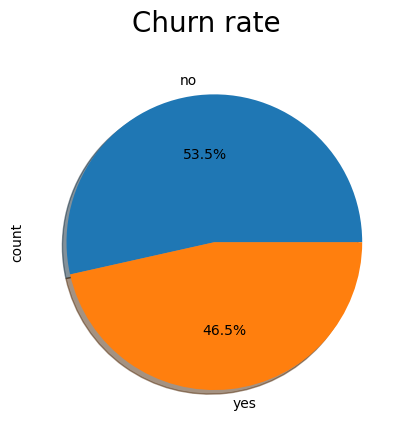

In [11]:


ca['churn'].value_counts().plot(kind='pie', autopct='%1.1f%%', shadow=True)
plt.suptitle('Churn rate',fontsize=20)


The Churn rate shows that 46.5% of customers churned while 53.5% stayed.

### Insight: 
This shows that nearly half of the customer base is being lost, indicating a significant retention problem.


## 2.  Which Contract type has the highest churn?

In [12]:
ca.groupby(['contract_type'])['churn'].value_counts(normalize=True)



contract_type   churn
1-Year          no       1.000000
2-Year          no       0.903226
                yes      0.096774
Month-to-Month  yes      1.000000
Name: proportion, dtype: float64

Text(0.5, 0.98, 'Contract Type vs Churn')

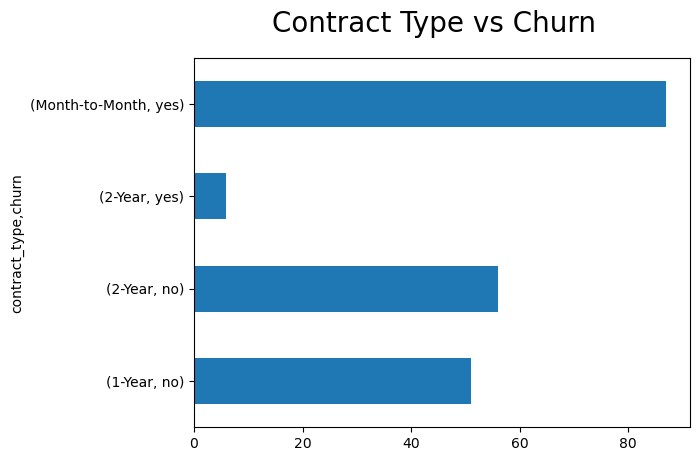

In [13]:
Contract= ca.groupby(['contract_type'])['churn'].value_counts()
Contract.plot(kind='barh')
plt.suptitle('Contract Type vs Churn',fontsize=20)

### Insight 
Customers on Month-to-Month contracts exhibit the highest churn, suggesting Low commitment increases likelyhood of leaving

## 3. Does higher monthly charge lead to churn?

In [14]:
ca.groupby(['churn'])['monthly_charges'].mean() 

churn
no     78.887850
yes    32.967742
Name: monthly_charges, dtype: float64

Text(0.5, 0.98, 'Monthly Charges vs Churn')

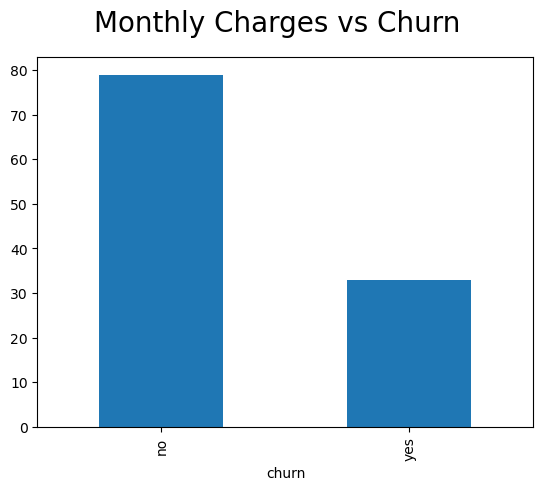

In [15]:
charges = ca.groupby(['churn'])['monthly_charges'].mean() 
charges.plot(kind='bar')
plt.suptitle('Monthly Charges vs Churn',fontsize=20)



### Insight:
Monthly charges alone does not appear to strongly drive churn.

## 4. Does customer engagement affect churn?

In [16]:
ca.groupby(['churn'])['num_logins_last_30days'].mean()


churn
no     34.757009
yes    10.258065
Name: num_logins_last_30days, dtype: float64

Text(0.5, 0.98, 'Customer Engagement vs Churn')

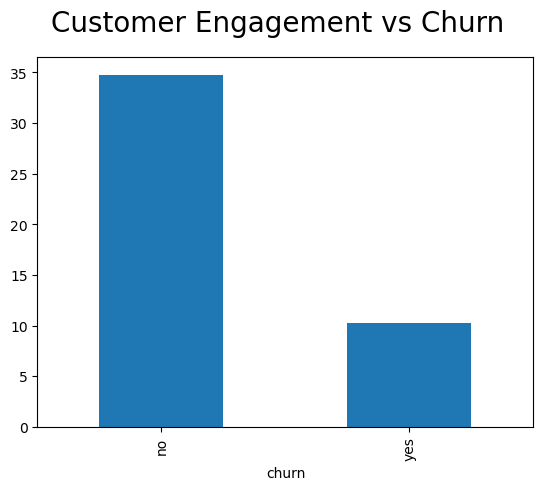

In [17]:
engagement=ca.groupby(['churn'])['num_logins_last_30days'].mean()
engagement.plot(kind='bar')
plt.suptitle('Customer Engagement vs Churn',fontsize=20)

### Insight:
Customers with lower engagement (less logins) show higher churn, indicating disengaged users are more likely to leave

## 5. Are support tickets linked to churn

In [18]:
ca.groupby(['churn'])['support_tickets'].mean()

churn
no     0.803738
yes    3.623656
Name: support_tickets, dtype: float64

Text(0.5, 0.98, 'Support Tickets vs Churn')

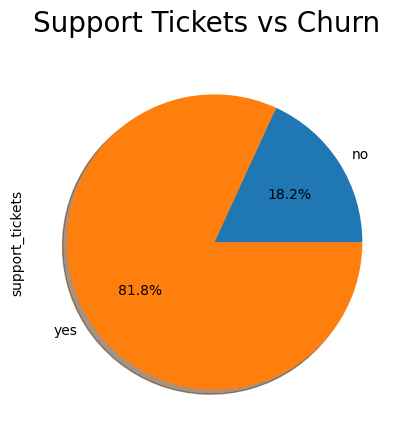

In [19]:
tickets=ca.groupby(['churn'])['support_tickets'].mean()
tickets.plot(kind='pie', autopct='%1.1f%%', shadow=True)
plt.suptitle('Support Tickets vs Churn',fontsize=20)

### Insight:
Customers with higher support tickets activities are more likely to churn, suggesting unresolved issues impacting retention 

## 6. Does tenure affect Churn?

In [20]:
ca.groupby(['churn'])['tenure_months'].mean()

churn
no     30.934579
yes     6.344086
Name: tenure_months, dtype: float64

Text(0.5, 0.98, 'Tenure Months vs Churn')

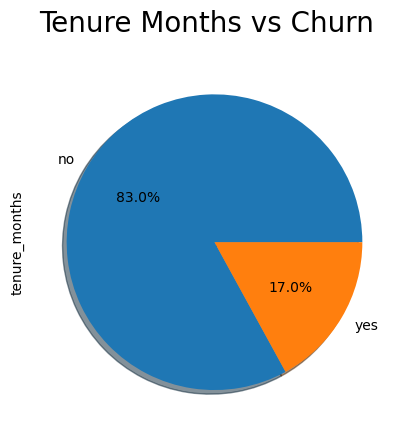

In [21]:
tenure= ca.groupby(['churn'])['tenure_months'].mean()
tenure.plot(kind='pie',autopct='%1.1f%%', shadow=True)
plt.suptitle('Tenure Months vs Churn',fontsize=20)

### Insight:
Customers with shorter tenure exhibit higher churn, indicating early stage retention is critical.

## 7. Which subscription type churns most?

In [22]:
ca.groupby(['subscription_type'])['churn'].value_counts(normalize=True)

subscription_type  churn
Basic              yes      1.000000
Premium            no       1.000000
Standard           no       0.632353
                   yes      0.367647
Name: proportion, dtype: float64

Text(0.5, 0.98, 'Subscription Type vs Churn')

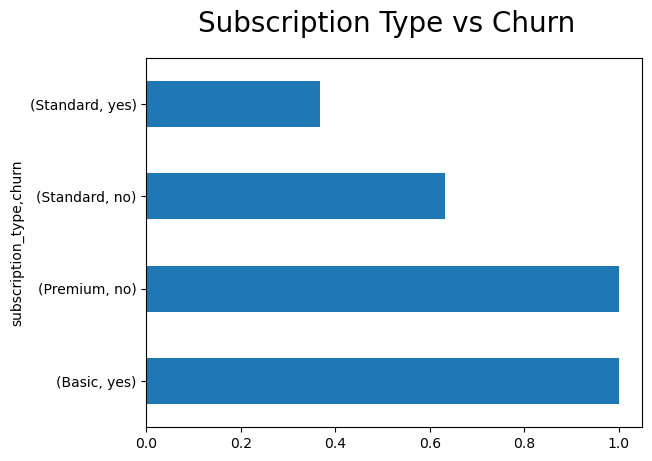

In [23]:
subscription= ca.groupby(['subscription_type'])['churn'].value_counts(normalize=True)
subscription.plot(kind='barh')
plt.suptitle('Subscription Type vs Churn',fontsize=20)

## 8. Does internet type affect churn?

In [24]:
ca.groupby(['internet_service'])['churn'].value_counts(normalize=True)

internet_service  churn
DSL               yes      0.632353
                  no       0.367647
Fiber             no       0.621212
                  yes      0.378788
Name: proportion, dtype: float64

Text(0.5, 0.98, 'Internet Service vs Churn')

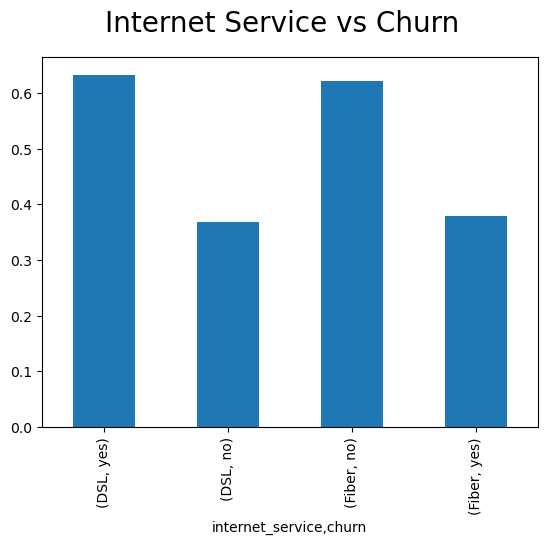

In [25]:
internet=ca.groupby(['internet_service'])['churn'].value_counts(normalize=True)
internet.plot(kind='bar')
plt.suptitle('Internet Service vs Churn', fontsize=20)

### Insight:
Customers using DSL Services show higher churn compared to fiber suggesting service quality difference may influence retention.

## 9. Is payment Method linked to churn?

In [26]:
ca.groupby(['payment_method'])['churn'].value_counts(normalize=True)

payment_method  churn
Bank Transfer   no       0.892857
                yes      0.107143
Cash            yes      1.000000
Credit Card     no       0.703125
                yes      0.296875
Debit Card      yes      0.675676
                no       0.324324
Name: proportion, dtype: float64

Text(0.5, 0.98, 'Payment Method vs Churn')

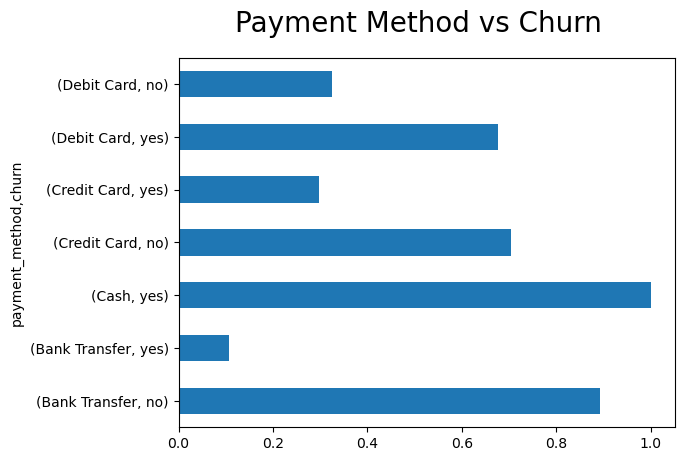

In [27]:
payment_method=ca.groupby(['payment_method'])['churn'].value_counts(normalize=True)
payment_method.plot(kind='barh')
plt.suptitle('Payment Method vs Churn', fontsize=20)

### insight:
Customers using cash payment methods show the highest churn, possibly due to lower convenience.

## 10. Predict high-risk customers.

In [ ]:
high_risk_customers=ca[(ca['tenure_months']<12) & (ca['support_tickets']>2) & (ca['num_logins_last_30days']<15)]


high_risk_customers


,date,customer_id,age,gender,tenure_months,subscription_type,monthly_charges,total_charges,payment_method,contract_type,internet_service,tech_support,streaming,device_protection,paperless_billing,avg_monthly_usage_gb,num_logins_last_30days,support_tickets,last_interaction_days,churn
4,16/01/2022,C005,45,Female,8,Basic,30,240,Cash,Month-to-Month,DSL,NO,NO,NO,NO,10,8,4,20,yes
7,19/01/2022,C008,22,Male,3,Basic,20,60,Cash,Month-to-Month,DSL,NO,NO,NO,YES,8,5,5,25,yes
9,21/01/2022,C010,27,Male,6,Basic,28,168,Credit Card,Month-to-Month,DSL,NO,NO,NO,NO,15,12,3,12,yes
13,25/01/2022,C014,33,Male,2,Basic,22,44,Cash,Month-to-Month,Fiber,NO,NO,NO,YES,9,6,6,30,yes
16,28/01/2022,C017,45,Female,8,Basic,30,240,Cash,Month-to-Month,DSL,NO,NO,NO,NO,10,8,4,20,yes
22,03/02/2022,C023,33,Male,2,Basic,22,44,Cash,Month-to-Month,Fiber,NO,NO,NO,YES,9,6,6,30,yes
28,09/02/2022,C029,45,Female,8,Basic,30,240,Cash,Month-to-Month,DSL,NO,NO,NO,NO,10,8,4,20,yes
31,12/02/2022,C032,22,Male,3,Basic,20,60,Cash,Month-to-Month,DSL,NO,NO,NO,YES,8,5,5,25,yes
33,14/02/2022,C034,27,Male,6,Basic,28,168,Credit Card,Month-to-Month,DSL,NO,NO,NO,NO,15,12,3,12,yes
37,18/02/2022,C038,33,Male,2,Basic,22,44,Cash,Month-to-Month,Fiber,NO,NO,NO,YES,9,6,6,30,yes


### Insight:
The above Customers have been identified as high-risk based on behavioural and demographic patterns

<Axes: >

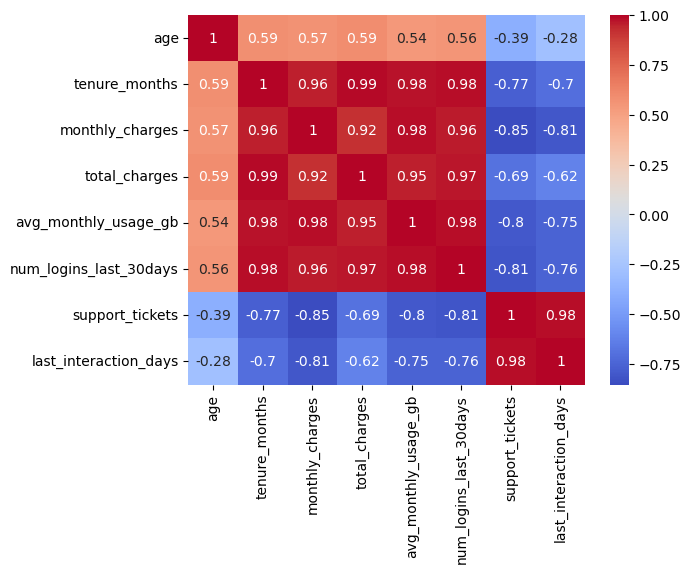

In [29]:
corr=ca.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap='coolwarm')

## Business Recommendation
1. Introduce incentives for long-term contracts eg (discounts, loyalty, benefits).
2. Focus on improving value perception (service quality) rather than pricing alone.
3. Improve engagement through targeted campaigns, notifications, and personalized experiences.
4. Strengthen onboarding and early customer experience.
5. Upsell basic users to higher plans and improve value offering at entry level tiers.
6. Encourage digital payments through incentives or ease-of-use.
7. Target high- risk customers with retention offers, personalized communication and proactive support.